In [107]:
from pathlib import Path
from typing import Optional, Tuple
import tifffile
from liffile import LifFile
import numpy as np
import napari
import os
from magicgui import magicgui
from magicgui.widgets import Container, TextEdit
from skimage import util
from skimage.filters import threshold_triangle, median, sobel, gaussian, threshold_yen, threshold_otsu
from skimage.measure import label, regionprops_table, regionprops, moments_central
from skimage.morphology import disk, remove_small_objects, remove_small_holes, closing, opening, binary_opening, binary_closing, erosion
from skimage.transform import ProjectiveTransform, warp, probabilistic_hough_line
from scipy.ndimage import rotate, binary_dilation, binary_fill_holes
from skimage.draw import line
from skimage.io import imread
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from skimage import exposure
from skimage.filters import threshold_multiotsu
from skimage.segmentation import expand_labels




In [14]:
image_folder = Path(r"Z:\\Bel\\Marina_Area_PDO\\260310")
png_stack = imread(r"z:\Bel\Marina_Area_PDO\260310\marina_area_stack.tif")
segmented_stack = imread(r"z:\Bel\Marina_Area_PDO\260310\marina_segmented_stack.tif")

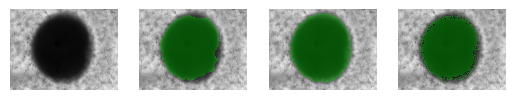

In [70]:
fig, ax = plt.subplots(ncols=4)
z = 3
image = png_stack[z, :, :]

eroded_labels = label(remove_small_holes(opening(segmented_stack[z, :, :] == 1, disk(2)), max_size = 5000))

binary = image < threshold_otsu(image)

organoid = np.zeros_like(eroded_labels, dtype=bool)
if eroded_labels.max() > 0:
    label_sizes = np.bincount(eroded_labels.ravel())
    label_sizes[0] = 0
    organoid = eroded_labels == label_sizes.argmax()
    organoid = expand_labels(organoid.astype(int), distance=15) > 0
    organoid = closing(organoid, disk(10))

ax[0].imshow(image, cmap="gray")
ax[1].imshow(image, cmap="gray")
ax[1].imshow(
    organoid.astype(int),
    cmap=ListedColormap(["black", "lime"]),
    alpha=np.where(organoid, 0.3, 0.0),
    interpolation="none",
)
ax[2].imshow(image, cmap="gray")
ax[2].imshow(
    (binary).astype(int),
    cmap=ListedColormap(["black", "lime"]),
    alpha=np.where(binary, 0.3, 0.0),
    interpolation="none",
)
ax[3].imshow(image, cmap="gray")
ax[3].imshow(
    (segmented_stack[z, :, :] == 1).astype(int),
    cmap=ListedColormap(["black", "lime"]),
    alpha=np.where(segmented_stack[z, :, :] == 1, 0.3, 0.0),
    interpolation="none",
)


for a in ax:
    a.axis("off")

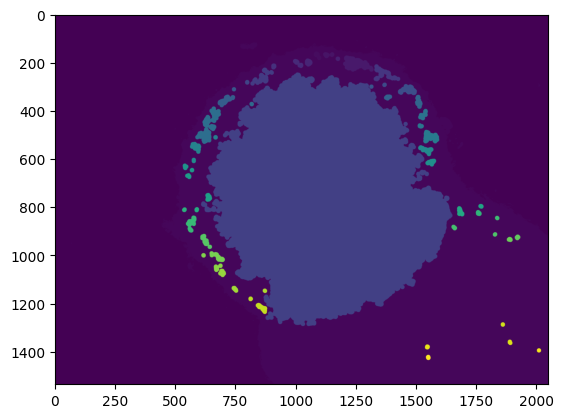

In [ ]:
total = binary a+ eroded_labels
plt.imshow(total)